# 7. Moving Camera Code Into Its Own Class

Good place to refactor.

What the book is doing is moving **camera math + render loop** into one class so the program becomes:

```python
world = HittableList()
...
cam = Camera()
cam.aspect_ratio = 16/9
cam.image_width = 400
cam.render(world)
```

instead of one giant `render()` function.

That gives:

| Before                             | After                        |
| ---------------------------------- | ---------------------------- |
| Everything in one function         | Organized into camera object |
| Hard to reuse                      | Easy to reuse                |
| Hard to change FOV/camera position | Easy                         |
| Mixes scene + rendering            | Separates responsibilities   |

---

# Full Python Version (with notes)

---

# `camera.py`

```python
import math
from util.ray import Ray
from util.vec3 import Vec3, unit_vector
from util.hit_record import HitRecord
from util.interval import Interval

INFINITY = float("inf")


class Camera:
    """
    Camera class handles:
    1. Building rays
    2. Rendering image
    """

    # -----------------------------------
    # PUBLIC VARIABLES
    # User can modify these directly
    # -----------------------------------
    def __init__(self):
        self.aspect_ratio = 16 / 9
        self.image_width = 400

    # -----------------------------------
    # MAIN RENDER FUNCTION
    # -----------------------------------
    def render(self, world):

        # Auto initialize before rendering
        self.initialize()

        with open("output.ppm", "w") as f:

            # PPM Header
            f.write(f"P3\n{self.image_width} {self.image_height}\n255\n")

            # Scan every pixel
            for j in range(self.image_height):
                for i in range(self.image_width):

                    # Get ray for current pixel
                    r = self.get_ray(i, j)

                    # Compute color
                    pixel_color = self.ray_color(r, world)

                    ir = int(255.999 * pixel_color.x)
                    ig = int(255.999 * pixel_color.y)
                    ib = int(255.999 * pixel_color.z)

                    f.write(f"{ir} {ig} {ib}\n")

        print("Done!")

    # -----------------------------------
    # INITIALIZATION
    # -----------------------------------
    def initialize(self):

        # Compute image height
        self.image_height = int(self.image_width / self.aspect_ratio)

        if self.image_height < 1:
            self.image_height = 1

        # Camera center
        self.center = Vec3(0, 0, 0)

        # Viewport setup
        focal_length = 1.0
        viewport_height = 2.0
        viewport_width = viewport_height * (
            self.image_width / self.image_height
        )

        # Horizontal vector
        viewport_u = Vec3(viewport_width, 0, 0)

        # Vertical vector
        viewport_v = Vec3(0, -viewport_height, 0)

        # Pixel size
        self.pixel_delta_u = viewport_u / self.image_width
        self.pixel_delta_v = viewport_v / self.image_height

        # Top-left viewport corner
        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        # First pixel center
        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (self.pixel_delta_u + self.pixel_delta_v)
        )

    # -----------------------------------
    # BUILD RAY FOR A PIXEL
    # -----------------------------------
    def get_ray(self, i, j):

        pixel_center = (
            self.pixel00_loc
            + self.pixel_delta_u * i
            + self.pixel_delta_v * j
        )

        ray_direction = pixel_center - self.center

        return Ray(self.center, ray_direction)

    # -----------------------------------
    # RAY COLOR LOGIC
    # -----------------------------------
    def ray_color(self, r, world):

        rec = HitRecord()

        if world.hit(r, Interval(0.001, INFINITY), rec):
            return 0.5 * (rec.normal + Vec3(1, 1, 1))

        unit_dir = unit_vector(r.direction())

        t = 0.5 * (unit_dir.y + 1.0)

        white = Vec3(1, 1, 1)
        blue = Vec3(0.5, 0.7, 1.0)

        return white * (1 - t) + blue * t
```

---

# New `main.py`

```python
from util.sphere import Sphere
from util.hittable_list import HittableList
from util.vec3 import Vec3
from camera import Camera

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400

cam.render(world)
```

---

# Learning Notes

---

# 1. Why Camera Class?

| Concept         | Meaning                                 |
| --------------- | --------------------------------------- |
| Encapsulation   | Group related logic together            |
| Reusability     | Same camera can render many worlds      |
| Clean code      | Main only builds scene                  |
| Easier upgrades | Add FOV, movement, depth of field later |

---

# 2. Image Height Formula

Inline:

$H = \frac{W}{A}$

Where:

* $H$ = image height
* $W$ = image width
* $A$ = aspect ratio

Purpose:

Keeps image proportions correct.

Example:

$$
H = \frac{400}{16/9} = 225
$$

---

# 3. Viewport Width Formula

Inline:

$V_w = V_h \cdot \frac{W}{H}$

Block:

$$
V_w = V_h \cdot \frac{W}{H}
$$

Purpose:

Makes viewport match image proportions.

---

# 4. Pixel Delta Formula

Horizontal:

$$
\Delta u = \frac{V_u}{W}
$$

Vertical:

$$
\Delta v = \frac{V_v}{H}
$$

Purpose:

Moves exactly one pixel in viewport.

---

# 5. Pixel Center Formula

$$
P(i,j) = P_{00} + i\Delta u + j\Delta v
$$

Where:

* $P_{00}$ = first pixel
* $i$ = column
* $j$ = row

Purpose:

Finds actual location of pixel.

---

# 6. Ray Formula

$$
R(t)=O+tD
$$

Where:

* $O$ = origin
* $D$ = direction

For camera:

$$
O = C
$$

$$
D = P(i,j)-C
$$

Purpose:

Shoots ray through pixel.

---

# 7. Hit Color Formula

Normal range:

$$
[-1,1]
$$

Convert to color:

$$
Color = 0.5(N+1)
$$

Purpose:

Maps negative normals into visible colors.

---

# 8. Sky Gradient Formula

Interpolation:

$$
L(a,b,t)=(1-t)a+tb
$$

Used as:

$$
(1-t)White+tBlue
$$

Where:

$$
t=0.5(y+1)
$$

Purpose:

Creates smooth sky.

---

# Full Flow Table

| Step           | Formula                        | Purpose             |
| -------------- | ------------------------------ | ------------------- |
| Image size     | $H=W/A$                        | Keep ratio          |
| Viewport size  | $V_w=V_h(W/H)$                 | Match screen        |
| Pixel spacing  | $\Delta = V/W$                 | Move pixel by pixel |
| Pixel position | $P=P_{00}+i\Delta u+j\Delta v$ | Locate pixel        |
| Ray direction  | $D=P-C$                        | Shoot ray           |
| Ray equation   | $R(t)=O+tD$                    | Travel ray          |
| Hit test       | sphere intersection            | Detect object       |
| Surface normal | $N=\frac{P-C}{r}$              | Surface direction   |
| Normal color   | $0.5(N+1)$                     | Convert to RGB      |
| Background     | $(1-t)A+tB$                    | Sky gradient        |

---

Structure now:

```text
main.py
   |
   | builds world
   v
Camera.render(world)
   |
   | initialize()
   | get_ray()
   | ray_color()
   v
output.ppm
```

This is the foundation for the next chapters: antialiasing, materials, reflections, and moving cameras.


# Camera 

In [11]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

from util.ray import Ray
from util.vec3 import Vec3
from util.color import write_color
from util.vec3 import unit_vector
from util.vec3 import dot
from tqdm import tqdm
from util.hit_record import HitRecord
from util.hittable import Hittable
from util.sphere import Sphere
from util.hittable_list import HittableList
import math

In [12]:
from util.ray import Ray
from util.vec3 import Vec3, unit_vector
from util.hit_record import HitRecord
from util.interval import Interval
import math

INFINITY = float("inf")


class Camera:
    """
    Camera class handles:
    1. Building rays
    2. Rendering image
    """

    # -----------------------------------
    # PUBLIC VARIABLES
    # User can modify these directly
    # -----------------------------------
    def __init__(self):
        self.aspect_ratio = 16 / 9
        self.image_width = 400

    # -----------------------------------
    # MAIN RENDER FUNCTION
    # -----------------------------------
    def render(self, world):

        # Auto initialize before rendering
        self.initialize()

        with open("output.ppm", "w") as f:

            # PPM Header
            f.write(f"P3\n{self.image_width} {self.image_height}\n255\n")

            # Scan every pixel
            for j in range(self.image_height):
                for i in range(self.image_width):

                    # Get ray for current pixel
                    r = self.get_ray(i, j)

                    # Compute color
                    pixel_color = self.ray_color(r, world)

                    ir = int(255.999 * pixel_color.x)
                    ig = int(255.999 * pixel_color.y)
                    ib = int(255.999 * pixel_color.z)

                    f.write(f"{ir} {ig} {ib}\n")

        print("Done!")

    # -----------------------------------
    # INITIALIZATION
    # -----------------------------------
    def initialize(self):

        # Compute image height
        self.image_height = int(self.image_width / self.aspect_ratio)

        if self.image_height < 1:
            self.image_height = 1

        # Camera center
        self.center = Vec3(0, 0, 0)

        # Viewport setup
        focal_length = 1.0
        viewport_height = 2.0
        viewport_width = viewport_height * (
            self.image_width / self.image_height
        )

        # Horizontal vector
        viewport_u = Vec3(viewport_width, 0, 0)

        # Vertical vector
        viewport_v = Vec3(0, -viewport_height, 0)

        # Pixel size
        self.pixel_delta_u = viewport_u / self.image_width
        self.pixel_delta_v = viewport_v / self.image_height

        # Top-left viewport corner
        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        # First pixel center
        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (self.pixel_delta_u + self.pixel_delta_v)
        )

    # -----------------------------------
    # BUILD RAY FOR A PIXEL
    # -----------------------------------
    def get_ray(self, i, j):

        pixel_center = (
            self.pixel00_loc
            + self.pixel_delta_u * i
            + self.pixel_delta_v * j
        )

        ray_direction = pixel_center - self.center

        return Ray(self.center, ray_direction)

    # -----------------------------------
    # RAY COLOR LOGIC
    # -----------------------------------
    def ray_color(self, r, world):

        rec = HitRecord()

        if world.hit(r, Interval(0.001, INFINITY), rec):
            return 0.5 * (rec.normal + Vec3(1, 1, 1))

        unit_dir = unit_vector(r.direction())

        t = 0.5 * (unit_dir.y + 1.0)

        white = Vec3(1, 1, 1)
        blue = Vec3(0.5, 0.7, 1.0)

        return white * (1 - t) + blue * t

In [13]:
from util.sphere import Sphere
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400

cam.render(world)

Done!


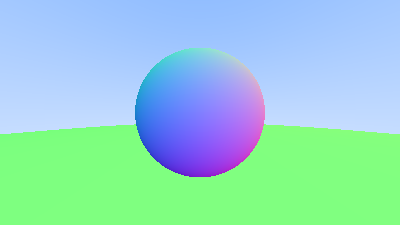

In [14]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")
from util.image_viewer import image_viewer
from util.scale_image import scale

a = image_viewer("output.ppm")
a

# Code Reduce

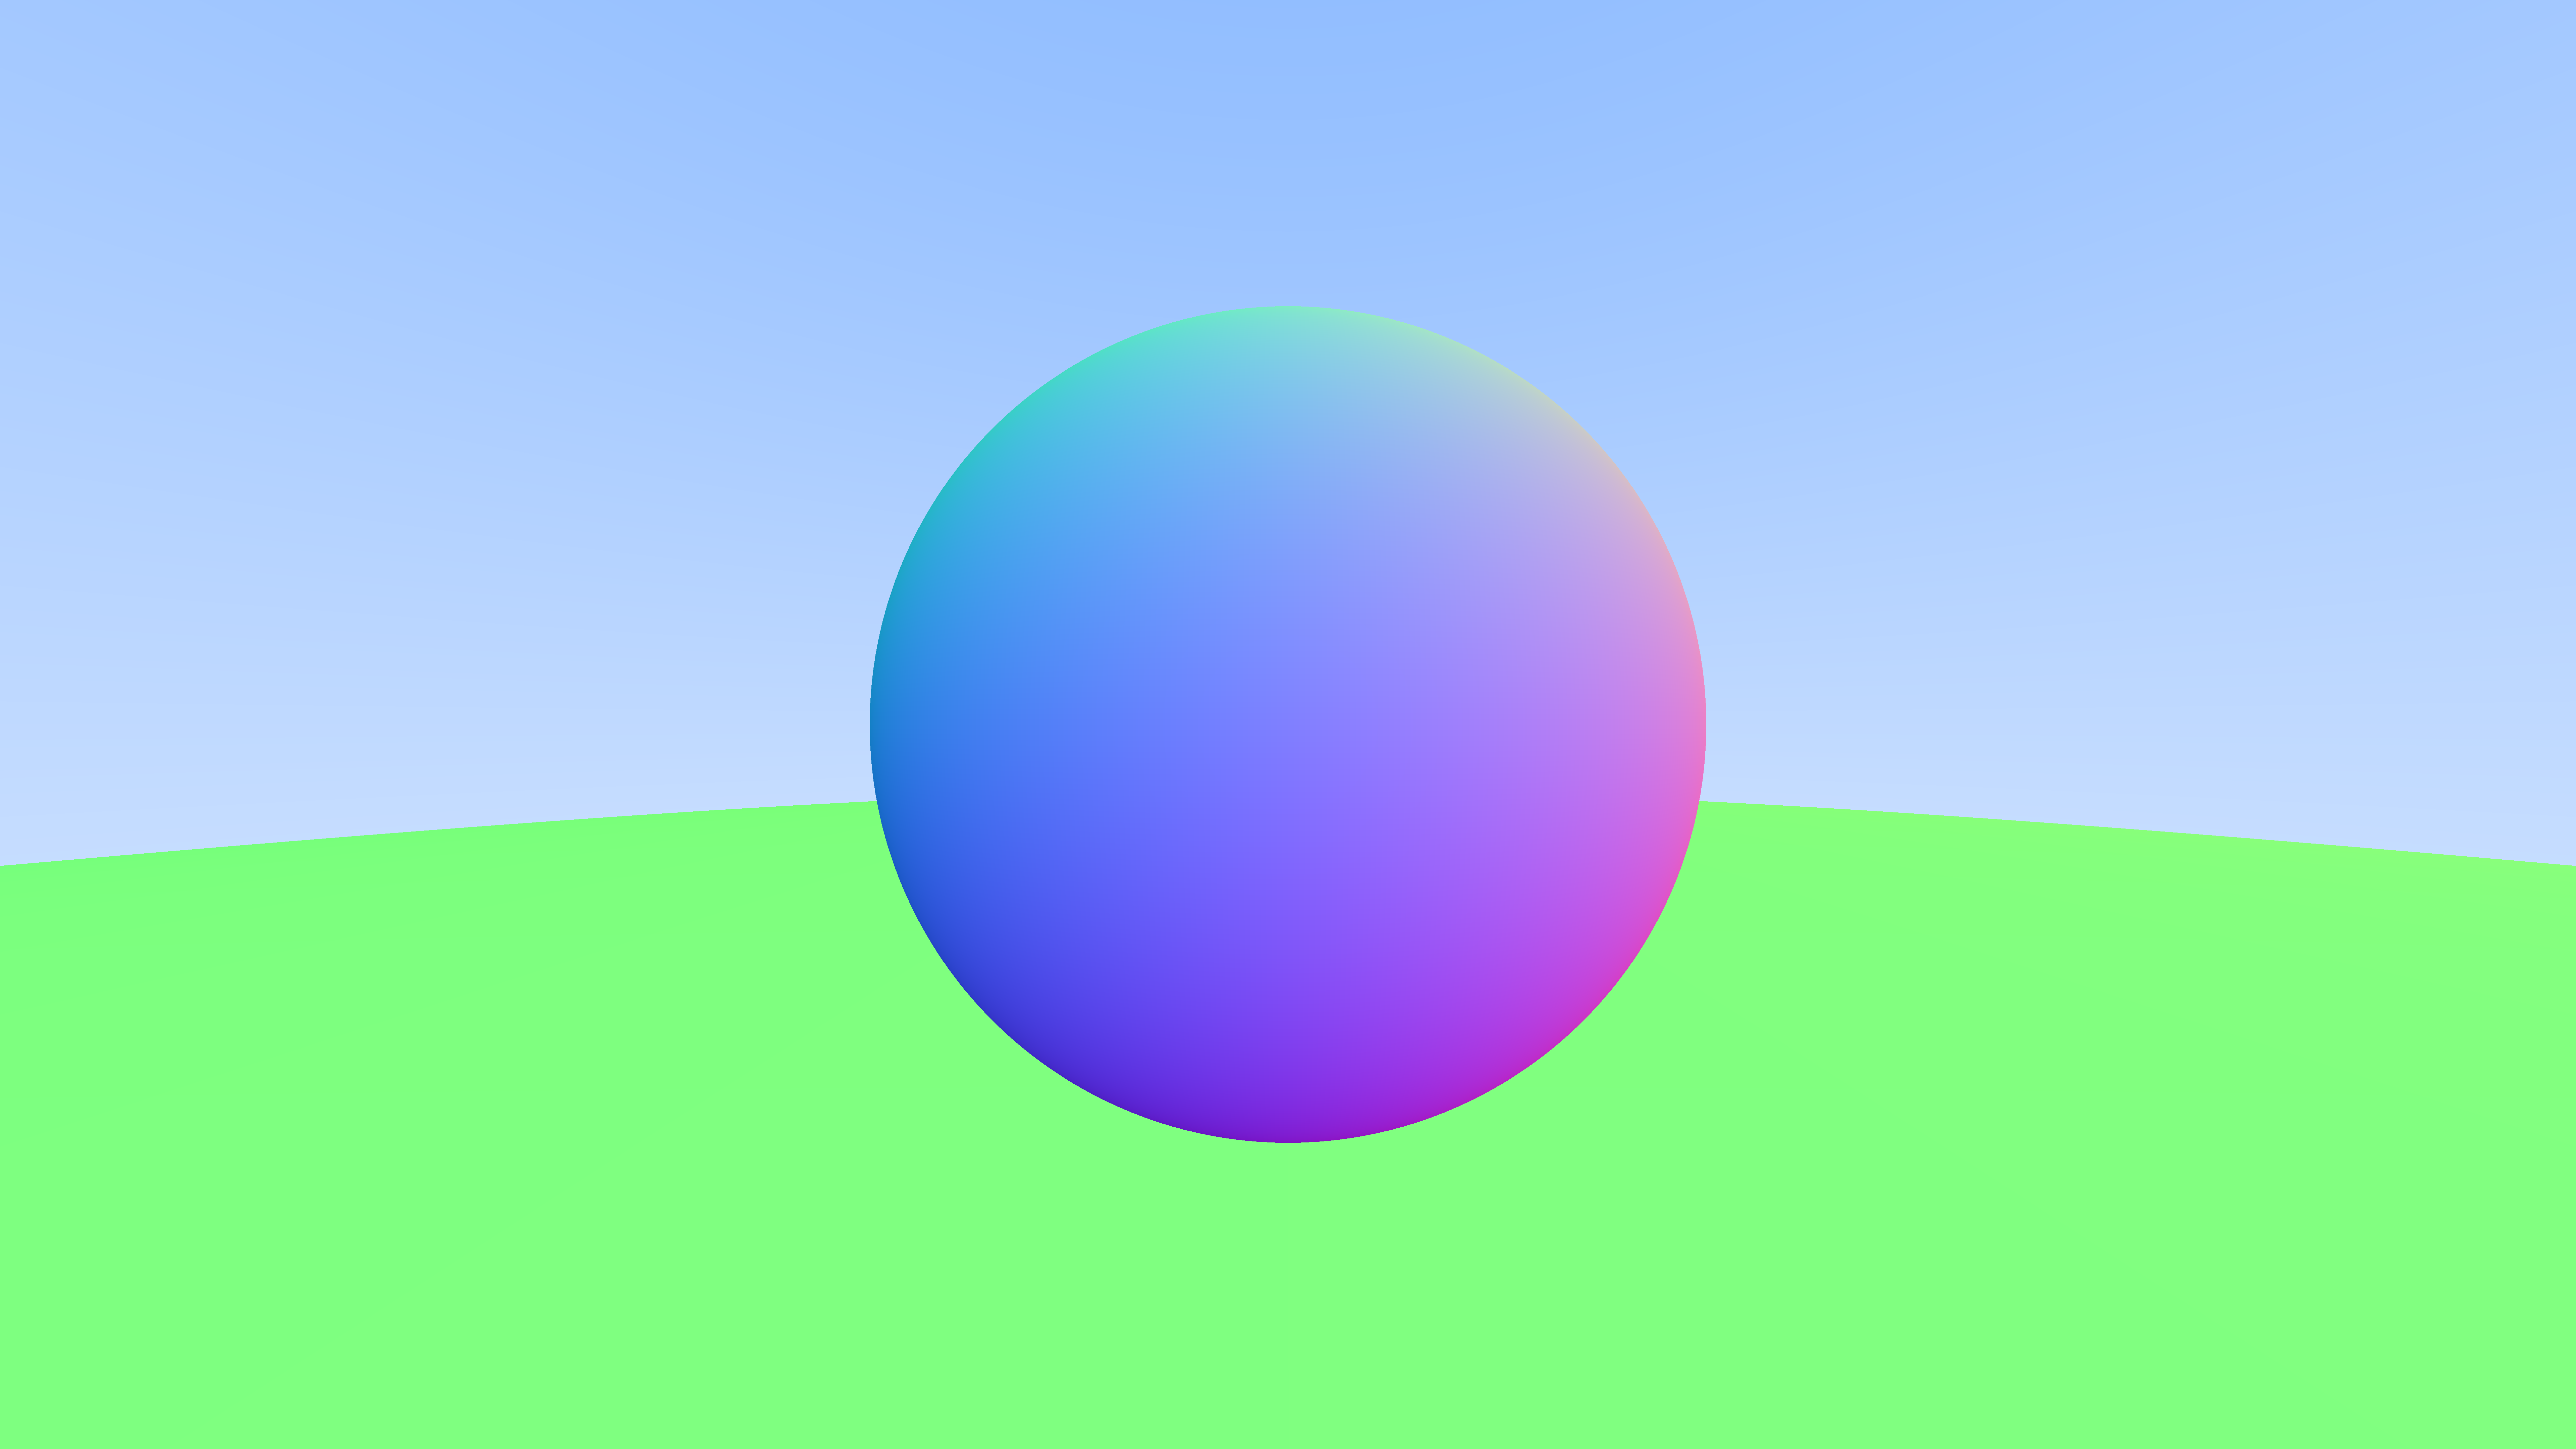

In [18]:
cam.show()